# Feature Scaling and Learning Rate

In [3]:
import numpy as np 
import matplotlib.pyplot as plt
import copy, math
np.set_printoptions(precision=2)

# Problem Statement 

We would like to build a linear regression model using these values so we can then predict the price for other houses - say, a house with 1200 sqft, 3 bedrooms, 1 floor, 40 years old

## Data Set: 
|Size(sqft) | Number of Bedrooms | Number of floors | Age of Home | Price (1000s dollars) |
| ----------------| ------------------- |----------------- |--------------|----------------------- | 
| 952             | 2                   | 1                | 65           | 271.5                  |  
| 1244            | 3                   | 2                | 64           | 232                    |  
| 1947            | 3                   | 2                | 17           | 509.8                  |  
| ...             | ...                 | ...              | ...          | ...                    

In [4]:
def load_house_data(): 
    data = np.loadtxt('houses.txt', delimiter=',', skiprows=1)
    X = data[:, :4]
    y = data[:, 4]
    return X, y

In [5]:
X_train, y_train = load_house_data()
X_features = ["Size (sqft", "Number of Bedrooms", "Number of floors" , "Age of Home"]

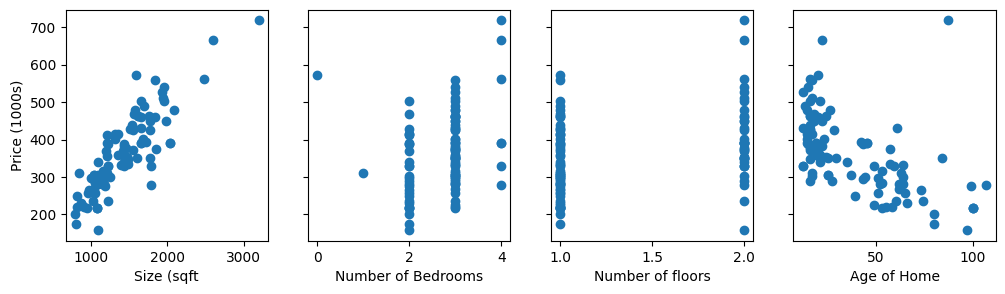

In [6]:
fig, ax=plt.subplots(1, 4, figsize=(12, 3), sharey=True)
for i in range(len(ax)): 
    ax[i].scatter(X_train[:, i], y_train)
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("Price (1000s)") 
plt.show()

Plotting each feature vs. the target, price, provides some indcication of which features have the strongest influence on price. Above, increasing size also increase size. Bedrooms and floors don't seem to have a strong impact on price. Newer houses have higher prices than the old houses. 

## Feature Scaling
The lectures described the importance of rescaling of the dataset so the features have a similar range.

### Details
Let's look again at the situation with $\alpha = 9e^{-7}$. This is pretty close to the maximum value we can set $\alpha$ without diverging. 

Initial $\frac{\partial J(\vec{w}, b)}{\partial w_o}$ is significanly larger than $\frac{\partial J(\vec{w}, b)}{\partial w_{1-3}}$  and $\frac{\partial J(\vec{w}, b)}{\partial b}$

Above, while cost is being decreased, its clear that $w_0$ is making more rapid progress than the other parameters due to its much larger gradient. 

The cost decreased slowly after its initial reduction. Notice the difference between `w0` and `w1`, `w2`, `w3` as well as `dj_dw0` and `dj_dw1-3`. `w0` reaches its near final value very quickly and `dj_dw0` has quickly decreased to a small value showing that `w0` is near the final vlaue. The other parameters were reduced much more slowly. 

Why is this? Is this something wrong we can improve? 

The figure aboves show why $w$'s are updated unevenly. 
* $\alpha$ is shared by all parameters updates ($w$'s and $b$)
* the common error term is multiplied by the features for the $w$'s (not b)
* The features vary significantly in magnitude making some features update much faster than the others. In this case, $w_0$ is multiplied by 'size(sqft)', which is generally > 1000, while $w_1$ is multiplied by 'number of bedrooms', which is generally 2-4

* Feature scaling, essentially dividing each positive feature by its maximum value, or more generally, rescale each feature by both its minimum and maximum values using (x-min)/(max-min). Both ways normalizes features to the range of -1 and 1, where the former method works for positive features which is simple.
* Mean normalization: $x_i := \frac{x_i - \mu_i}{max - min}$
* Z-score normalization

### z-score normalization 
After z-score normalization, all features will have a mean of 0 and a standard deviation of 1
To implement z-score normalization, adjust your input values as shown in this formula: 
$$x_j^{(i)} = \frac{x_j^{(i)} - \mu_j}{\sigma_j}$$
where j selects a feature or a column in the $\mathbf{X}$ matrix. 
$$\mu_j = \frac{1}{m}\sum\limits_{i = 0}^{m - 1} x_j^{(i)}$$
$$\sigma_j^{2} = \frac{1}{m}\sum\limits_{i = 0}^ {m - 1}(x_j^{(i)} - \mu_j)^{2}$$

In [7]:
def z_score_normalize_features(X): 
    """
    Computes X, zscore normalized by column 

    X (ndarray(m, n)) 

    Return 
        X_norm (ndarray(m, n)) 
        mu (ndarray(n, )) 
        sigma (ndarray(n, ))
    """

    mu = np.mean(X, axis=0) 
    sigma = np.std(X, axis=0) 
    X_norm = (X - mu) / sigma

    return (X_norm, mu, sigma) 

Let's look at the steps involved in Z-score normalization. The plot below shows the transformation step by step

Text(0.5, 0.98, 'distribution of features before, during, after normalization')

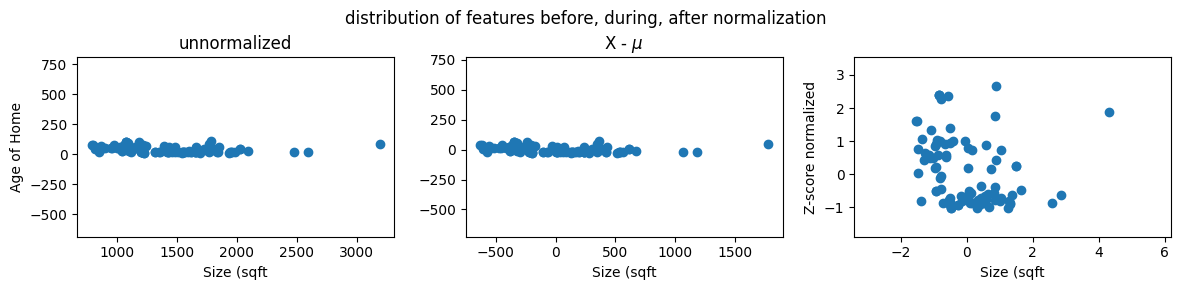

In [9]:
mu = np.mean(X_train, axis=0) 
sigma = np.std(X_train, axis=0) 
X_mean = (X_train - mu) # broadcasting in numPy 
X_norm = (X_train - mu) / sigma

fig, ax=plt.subplots(1, 3, figsize=(12, 3))
ax[0].scatter(X_train[:, 0], X_train[:, 3])
ax[0].set_xlabel(X_features[0]); ax[0].set_ylabel(X_features[3]);
ax[0].set_title("unnormalized") 
ax[0].axis('equal')

ax[1].scatter(X_mean[:, 0], X_mean[:, 3]); ax[0].set_ylabel(X_features[3]); 
ax[1].set_xlabel(X_features[0])
ax[1].set_title(r"X - $\mu$") 
ax[1].axis('equal')

ax[2].scatter(X_norm[:, 0], X_norm[:, 3]) 
ax[2].set_xlabel(X_features[0]); ax[0].set_ylabel(X_features[3]);
ax[2].set_ylabel(r"Z-score normalized") 
ax[2].axis('equal')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
fig.suptitle("distribution of features before, during, after normalization") 

The plot above shows the relationship between two of the training set parameters, "age" and "size(sqft)". *These are plotted with equal scale* 
* Left: Unnormalized: The range of values or the variance of the 'size(sqft)' feature is much larger than that of age
* Middle: The first step remvoes the mean or average value from each feature. This leaves features that are centered around zero. It's difficult to see the difference for the 'age' feature', but 'size(sqft)' is clearly around zero
* Right: The second step divides by the standard deviation. This leaves both features centered at zero with a similar scale. 

In [10]:
X_norm, X_mu, X_sigma = z_score_normalize_features(X_train)
print(f"X_mu = {X_mu}, \nX_sigma = {X_sigma}")
print(f"Peak to Peak range by column in Raw:        X:{np.ptp(X_train, axis=0)}") 
print(f"Peak to Peak range by column in Normalized  X:{np.ptp(X_norm, axis=0)}")

X_mu = [1.42e+03 2.72e+00 1.38e+00 3.84e+01], 
X_sigma = [411.62   0.65   0.49  25.78]
Peak to Peak range by column in Raw:        X:[2.41e+03 4.00e+00 1.00e+00 9.50e+01]
Peak to Peak range by column in Normalized  X:[5.85 6.14 2.06 3.69]


The peak to peak range of each column is reduced from a factor of thousands to a factor of 2-3 by normalization

In [11]:
def compute_gradient_matrix(X, y, w, b): 
    m, n = X.shape 
    f_wb = X @ w + b
    e = f_wb - y 
    dj_dw = (1/m) * (X.T @ e) 
    dj_db = (1/m) * np.sum(e)
    return dj_dw, dj_db

In [12]:
def compute_cost(X, y, w, b): 
    m = X.shape[0]
    cost = 0.0 
    for i in range(m): 
        f_wb_i = np.dot(X[i], w) + b
        cost = cost + (f_wb_i - y[i])**2 
    cost = cost / (2*m)
    return cost

In [19]:
def gradient_descent_houses(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters):
    m = len(X) 
    hist = {}
    hist["cost"] = []; hist["params"] = []; hist["grads"] = []; hist["iter"] = []; 
    w = copy.deepcopy(w_in) 
    b = b_in 
    save_interval = np.ceil(num_iters/10000)

    for i in range(num_iters): 
        dj_dw, dj_db = gradient_function(X, y, w, b)

        w = w - alpha * dj_dw 
        b = b - alpha * dj_db 

        cost = cost_function(X, y, w, b)
                # Save cost J,w,b at each save interval for graphing
        if i == 0 or i % save_interval == 0:     
            hist["cost"].append(cost_function(X, y, w, b))
            hist["params"].append([w,b])
            hist["grads"].append([dj_dw,dj_db])
            hist["iter"].append(i)
        if i % math.ceil(num_iters / 10) == 0: 
            print(f"Iteration {i:4d}: w = {w}, b = {b:4f}, cost = {cost:4f}")

    return w, b, hist

In [14]:
def run_gradient_descent(X, y, iterations=1000, alpha=1e-6): 
    m, n = X.shape 
    initial_w = np.zeros(n) 
    initial_b = 0
    w_out, b_out, hist_out = gradient_descent_houses(X, y, initial_w, initial_b, compute_cost, compute_gradient_matrix, alpha, iterations)

    return w_out, b_out, hist_out

In [21]:
w_norm, b_norm, hist = run_gradient_descent(X_norm, y_train, 1000, 1.0e-1,)
print(w_norm, b_norm)

Iteration    0: w = [ 8.91  2.95  3.28 -5.96], b = 36.315608, cost = 57617.032522
Iteration  100: w = [107.92 -19.95 -31.2  -38.48], b = 363.147399, cost = 221.085627
Iteration  200: w = [110.47 -21.22 -32.66 -37.99], b = 363.156081, cost = 219.208900
Iteration  300: w = [110.56 -21.27 -32.71 -37.97], b = 363.156081, cost = 219.206827
Iteration  400: w = [110.56 -21.27 -32.71 -37.97], b = 363.156081, cost = 219.206824
Iteration  500: w = [110.56 -21.27 -32.71 -37.97], b = 363.156081, cost = 219.206824
Iteration  600: w = [110.56 -21.27 -32.71 -37.97], b = 363.156081, cost = 219.206824
Iteration  700: w = [110.56 -21.27 -32.71 -37.97], b = 363.156081, cost = 219.206824
Iteration  800: w = [110.56 -21.27 -32.71 -37.97], b = 363.156081, cost = 219.206824
Iteration  900: w = [110.56 -21.27 -32.71 -37.97], b = 363.156081, cost = 219.206824
[110.56 -21.27 -32.71 -37.97] 363.15608080808056


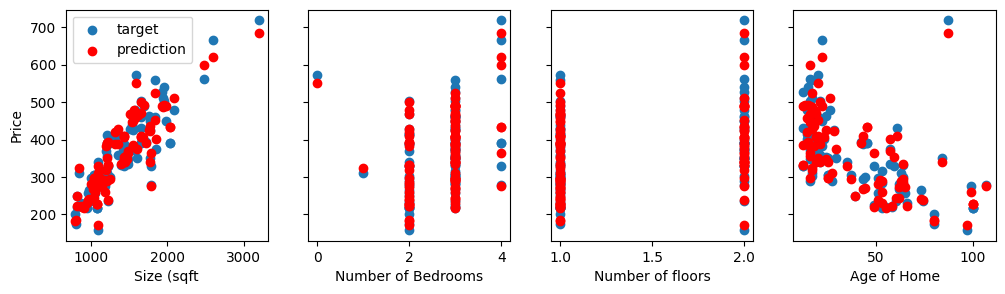

In [83]:
m = X_norm.shape[0]
yp = np.zeros(m)
for i in range(m): 
    yp[i] = np.dot(X_norm[i], w_norm) + b_norm 
fig, ax = plt.subplots(1, 4, figsize=(12, 3), sharey=True) 
for i in range(len(ax)): 
    ax[i].scatter(X_train[:, i], y_train, label='target') 
    ax[i].set_xlabel(X_features[i]) 
    ax[i].scatter(X_train[:, i], yp, color='r', label='prediction')
ax[0].set_ylabel("Price"); ax[0].legend()